In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
# 1. 데이터 로드 경로 설정
DATA_DIR = '/home/minkyujeong/.cache/kagglehub/datasets/raddar/chest-xrays-indiana-university/versions/2' 
IMAGE_DIR = "/home/minkyujeong/.cache/kagglehub/datasets/raddar/chest-xrays-indiana-university/versions/2/images/images_normalized"

reports_path = os.path.join(DATA_DIR, 'indiana_reports.csv')
projections_path = os.path.join(DATA_DIR, 'indiana_projections.csv')

df_reports = pd.read_csv(reports_path)
df_projections = pd.read_csv(projections_path)

print("# of reports: ", len(df_reports))
print("# of projections: ", len(df_projections))

# of reports:  3851
# of projections:  7466


In [3]:
df_reports.head()


,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [4]:
df_projections.head()

,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal


In [5]:
# 2. 고도화된 데이터 정제 (결측치 및 무의미한 'XXXX' 문자열 처리)
df_reports['findings'] = df_reports['findings'].fillna('').str.strip()
df_reports['impression'] = df_reports['impression'].fillna('').str.strip()
df_reports['MeSH'] = df_reports['MeSH'].fillna('').str.strip()

# [필터링 1] 둘 다 완전히 비어있거나, 의미 없는 'XXXX' 기호나 공백만 도배된 경우 제거
def is_invalid_report(row):
    text = row['findings'].replace('X', '').replace('x', '').strip()
    return len(text) < 10
    # 비식별화 기호를 지웠더니 남은 글자가 거의 없는 쓰레기 데이터 판정
    return len(text) < 10

invalid_mask = df_reports.apply(is_invalid_report, axis=1)
df_reports = df_reports[~invalid_mask].reset_index(drop=True)

In [6]:
len(df_reports)

3337

In [7]:
# 3. 정상(Normal) vs 비정상(Abnormal) 라벨링
def define_label(row):
    combined_text = (row['findings'] + " " + row['impression']).lower()
    mesh_text = row['MeSH'].lower()
    
    is_normal_text = 'normal' in combined_text or 'no acute' in combined_text or 'normal' in mesh_text
    abnormal_flags = ['cardiomegaly', 'effusion', 'pneumonia', 'infiltrat', 'nodule', 'opacity', 'edema', 'pneumothorax']
    has_abnormal_flag = any(flag in combined_text or flag in mesh_text for flag in abnormal_flags)
    
    if is_normal_text and not has_abnormal_flag:
        return 'Normal'
    else:
        return 'Abnormal'

df_reports['rough_label'] = df_reports.apply(define_label, axis=1)

In [8]:
df_reports['rough_label'].value_counts()

rough_label
Abnormal    2928
Normal       409
Name: count, dtype: int64

In [9]:
df_reports['rough_label'].value_counts(normalize=True)

rough_label
Abnormal    0.877435
Normal      0.122565
Name: proportion, dtype: float64

In [10]:

# 3. 촘촘한 정밀 라벨링 함수 (부정어 처리 + 키워드 확장)
def define_label_advanced(row):
    combined_text = (row['findings'] + " " + row['impression']).lower()
    mesh_text = row['MeSH'].lower()
    
    # [확장된 이상 소견 키워드 마스터 리스트]
    abnormal_keywords = [
        'cardiomegaly', 'effusion', 'pneumonia', 'infiltrat', 'nodule', 'opacity', 
        'edema', 'pneumothorax', 'scoliosis', 'emphysema', 'granuloma', 'mass', 
        'scarring', 'atelectasis', 'blunting', 'fracture', 'deformity', 'enlargement',
        'calcification', 'congestion', 'prominence', 'adenopathy', 'tortuous', 'ectasia'
    ]
    
    # [부정어 리스트] - 이상 징후가 "없다"고 할 때 쓰이는 단어들
    negation_words = ['no ', 'negative', 'normal', 'clear', 'free of', 'without']
    
    # 문장 단위로 쪼개서 정밀 분석
    # (전체 문장에 단순히 단어가 있는 지 보면 "No pneumonia"를 이상 소견으로 잡기 때문)
    sentences = combined_text.split('.') + mesh_text.split(';')
    
    detected_abnormalities = 0
    
    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue
            
        # 해당 문장에 이상 소견 키워드가 존재하는지 확인
        has_keyword = any(bug in sentence for bug in abnormal_keywords)
        
        if has_keyword:
            # 해당 문장에 부정어(No, Clear 등)가 함께 들어있는지 확인
            has_negation = any(neg in sentence for neg in negation_words)
            
            # 키워드는 있지만 부정어가 없다면 -> 진짜 비정상 소견 발생
            if not has_negation:
                detected_abnormalities += 1
                
    # 4. 최종 판정
    # 문장들을 분석했을 때 실질적인 비정상 징후 문장이 1개라도 나왔다면 Abnormal
    if detected_abnormalities > 0:
        return 'Abnormal'
    
    # 명시적으로 'normal', 'clear', 'no acute'가 들어가 있거나, 이상 소견이 발견되지 않은 경우
    is_normal_sign = any(norm in combined_text or norm in mesh_text for norm in ['normal', 'clear', 'no acute', 'unremarkable'])
    if is_normal_sign and detected_abnormalities == 0:
        return 'Normal'
        
    # 그 외 기본값은 보수적으로 안정성을 위해 Abnormal 처리
    return 'Abnormal'

df_reports['label'] = df_reports.apply(define_label_advanced, axis=1)


In [11]:
df_reports['label'].value_counts()

label
Normal      1806
Abnormal    1531
Name: count, dtype: int64

In [12]:
df_reports['label'].value_counts(normalize=True)

label
Normal      0.541205
Abnormal    0.458795
Name: proportion, dtype: float64

In [13]:
df_reports[(df_reports['rough_label'] == "Abnormal") & (df_reports['label'] == "Normal")].head()

,uid,MeSH,Problems,image,indication,comparison,findings,impression,rough_label,label
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,Abnormal,Normal
3,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,Abnormal,Normal
4,6,normal,normal,"PA and Lateral Chest. XXXX, XXXX at XXXX",Evaluate for infection,"XXXX, XXXX",Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.,Abnormal,Normal
6,8,normal,normal,Xray Chest PA and Lateral,XXXX-year-old with XXXX on XXXX. Dyspnea. Hist...,Two views of the chest dated XXXX.,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.,Abnormal,Normal
9,11,normal,normal,Xray Chest PA and Lateral,"Fatigue, weakness, anterior chest pain",NaN,Cardiomediastinal silhouette and pulmonary vas...,No acute cardiopulmonary findings.,Abnormal,Normal


In [14]:
df_reports[(df_reports['rough_label'] == "Normal") & (df_reports['label'] == "Abnormal")].head()

,uid,MeSH,Problems,image,indication,comparison,findings,impression,rough_label,label
26,32,Costophrenic Angle/right/blunted/mild,Costophrenic Angle,Xray Chest PA and Lateral,WEAKNESS OF MUSCLES; hx XXXX nodules; XXXX for...,NaN,The heart is normal in size. The mediastinum i...,No acute disease.,Normal,Abnormal
43,51,Calcified Granuloma/lung/bilateral/scattered,Calcified Granuloma,"CHEST 2V FRONTAL/LATERAL XXXX, XXXX XXXX XXXX",preop XXXX,"Chest 2 views from XXXX, XXXX. .",Heart size is normal and cardiomediastinal sil...,No acute cardiopulmonary abnormality.,Normal,Abnormal
50,58,Thoracic Vertebrae/degenerative;Scoliosis/thor...,Thoracic Vertebrae;Scoliosis,CHEST 2V FRONTAL/LATERAL,Left arm numbness,NaN,The heart is normal in size. The mediastinum i...,No acute disease.,Normal,Abnormal
63,74,Calcified Granuloma/lung/left;Atherosclerosis/...,Calcified Granuloma;Atherosclerosis;Kyphosis;D...,"PA and lateral chest XXXX, XXXX.",Bilateral rib pain and shortness of breath.,NaN,Lungs appear to be clear other than a calcifie...,No acute pulmonary disease. Multiple thoracic ...,Normal,Abnormal
124,147,normal,normal,"PA and lateral views of the chest, XXXX, XXXX ...",Preprocedure evaluation prior to bone marrow t...,NaN,The lungs are clear. Heart and pulmonary XXXX ...,1. No acute cardiopulmonary disease,Normal,Abnormal


In [15]:
# ==========================================
# 4. 이미지 조인 및 전면(Frontal) 필터링 + 물리적 파일 검수
# ==========================================
print("4. 전면(Frontal) 사진 필터링 및 디스크 내 실제 파일 존재 여부 검사 중...")
df_merged = pd.merge(df_projections, df_reports, on='uid', how='inner')
df_frontal = df_merged[df_merged['projection'].str.lower() == 'frontal'].reset_index(drop=True)

# 물리적 파일 존재 여부 마스크 생성
def check_file_exists(filename):
    full_path = os.path.join(IMAGE_DIR, str(filename))
    return os.path.exists(full_path)

file_exists_mask = df_frontal['filename'].apply(check_file_exists)
df_frontal = df_frontal[file_exists_mask].reset_index(drop=True)

# 환자 고유 ID 기준으로 분포 베이스라인 계산을 위한 중복 제거 데이터 생성
df_unique_patients = df_frontal.drop_duplicates(subset=['uid']).copy()

4. 전면(Frontal) 사진 필터링 및 디스크 내 실제 파일 존재 여부 검사 중...


In [16]:
print(len(df_frontal))
print(len(df_unique_patients))

3307
3199


In [17]:
# ==========================================
# 5. 분포 보존형 층화 추출 (Stratified Split) - [1인 1사진 반영본]
# ==========================================
# [중요] 이미 위에서 df_unique_patients를 만들 때 환자당 1장의 대표 사진만 남기고 중복을 지웠습니다.
# 따라서 len(df_unique_patients)가 곧 '총 환자 수'이자 '총 이미지 수'가 됩니다.

target_size = 800
split_ratio = target_size / len(df_unique_patients)

# 만약 데이터가 800개보다 적어서 비율이 1을 넘어가면 1.0(전체 선택)으로 제한하는 가드레일
if split_ratio > 1.0:
    split_ratio = 1.0

print(f"5. 환자당 1장씩, 총 {target_size}명의 환자(이미지 800장)를 층화 추출 중...")

# 1인 1사진인 상태의 테이블을 그대로 쪼갭니다.
df_final_report, _ = train_test_split(
    df_unique_patients,
    train_size=split_ratio,
    stratify=df_unique_patients['label'],
    random_state=42 # 고정 시드
)

# 인덱스만 깔끔하게 정리
df_final_report = df_final_report.reset_index(drop=True)

5. 환자당 1장씩, 총 800명의 환자(이미지 800장)를 층화 추출 중...


In [18]:
800 / len(df_unique_patients)

0.25007814942169426

In [19]:
print(len(df_final_report))
df_final_report['label'].value_counts()

800


label
Normal      435
Abnormal    365
Name: count, dtype: int64

In [20]:
df_final_report.head()

,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression,rough_label,label
0,3252,3252_IM-1542-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,ECF placement.,Chest x-XXXX of XXXX,No evidence of airspace opacity. No effusion o...,No acute cardiopulmonary abnormality. .,Abnormal,Normal
1,2039,2039_IM-0683-1001.dcm.png,Frontal,Calcified Granuloma/lung/hilum/right/multiple/...,Calcified Granuloma;Spinal Fusion,Xray Chest PA and Lateral,Shortness of breath after cervical spine surgery.,None.,Cardiac and mediastinal contours are within no...,No acute pulmonary findings.,Normal,Abnormal
2,1594,1594_IM-0385-1001.dcm.png,Frontal,normal,normal,PA and lateral chest radiographs.,XXXX-year-old male with chest pain.,None.,The heart and cardiomediastinal silhouette are...,No acute cardiopulmonary finding.,Abnormal,Normal
3,718,718_IM-2280-1001.dcm.png,Frontal,Scoliosis/mild,Scoliosis,Xray Chest PA and Lateral,XXXX for 3 weeks,NaN,The lungs are clear. There is no pleural effus...,No acute pulmonary disease.,Abnormal,Abnormal
4,3593,3593_IM-1772-1001.dcm.png,Frontal,normal,normal,"and lateral chest XXXX, XXXX at XXXX for comp...",hemoptysis.,NaN,Heart size normal. Lungs are clear. XXXX are n...,Normal chest,Abnormal,Normal


In [21]:
# ==========================================
# 7. 최종 결과 파일 저장 및 리포트 요약 출력
# ==========================================
output_filename = 'final_chest_xray_test_800_unique.csv'
df_final_report.to_csv(output_filename, index=False)

print("\n================ 🎯 최종 생성 리포트 통계 ================")
print(f"▶ 저장된 파일명: {output_filename}")
print(f"▶ 총 행(Row) 수: {len(df_final_report)}줄 (이미지 800장)")
print(f"▶ 포함된 고유 환자(uid) 수: {df_final_report['uid'].nunique()}명 (1인 1사진 완벽 일치)")
print("\n[최종 클래스별 데이터 카운트]")
print(df_final_report['label'].value_counts())
print("==========================================================")


================ 🎯 최종 생성 리포트 통계 ================
▶ 저장된 파일명: final_chest_xray_test_800_unique.csv
▶ 총 행(Row) 수: 800줄 (이미지 800장)
▶ 포함된 고유 환자(uid) 수: 800명 (1인 1사진 완벽 일치)

[최종 클래스별 데이터 카운트]
label
Normal      435
Abnormal    365
Name: count, dtype: int64


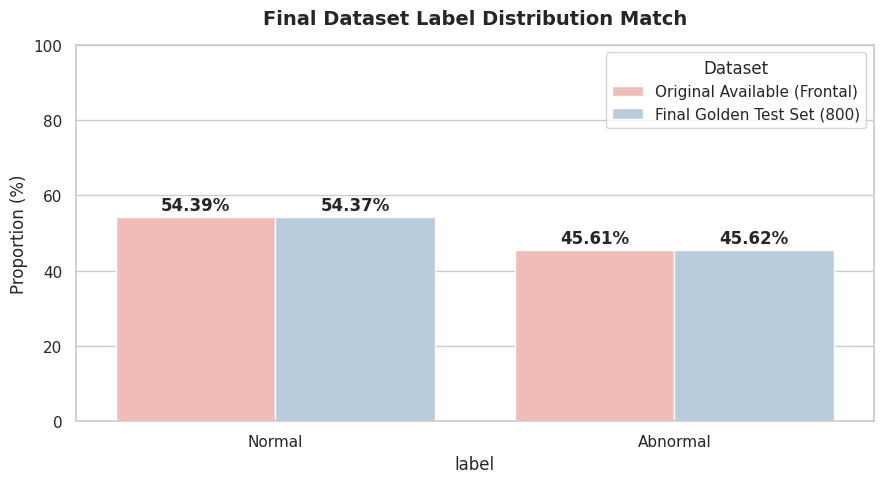

In [22]:
# ==========================================
# 6. 원본 vs 최종 리포트 분포 비교 시각화
# ==========================================
original_dist = df_unique_patients['label'].value_counts(normalize=True).rename('Percentage').reset_index()
original_dist['Dataset'] = 'Original Available (Frontal)'

test_dist = df_final_report['label'].value_counts(normalize=True).rename('Percentage').reset_index()
test_dist['Dataset'] = 'Final Golden Test Set (800)'

df_plot = pd.concat([original_dist, test_dist], axis=0)
df_plot['Percentage'] = df_plot['Percentage'] * 100

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='label', y='Percentage', hue='Dataset', data=df_plot, palette='Pastel1')
plt.title('Final Dataset Label Distribution Match', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Proportion (%)')
plt.ylim(0, 100)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_34949/1643360016.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=images_per_patient, ax=axes[1], palette='Pastel2')


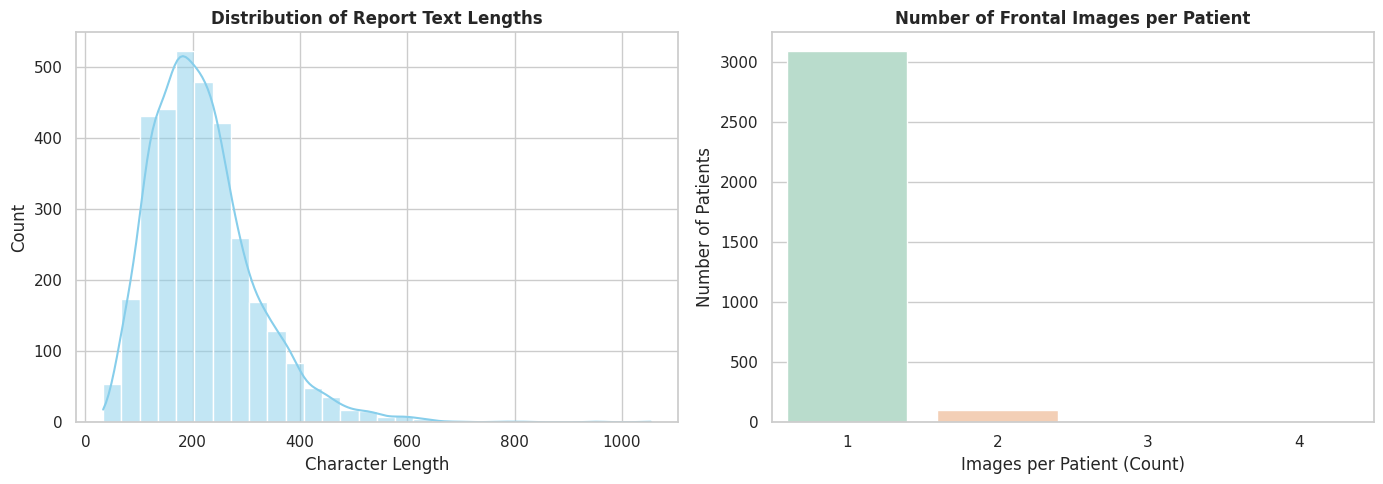

In [24]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [분석 1] 텍스트 글자 수 분포 확인 (Findings + Impression)
text_lengths = df_frontal['findings'].apply(len)
sns.histplot(text_lengths, bins=30, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Distribution of Report Text Lengths', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Count')

# [분석 2] 환자 1명당 Frontal 이미지 장수 분포 확인
images_per_patient = df_frontal['uid'].value_counts()
sns.countplot(x=images_per_patient, ax=axes[1], palette='Pastel2')
axes[1].set_title('Number of Frontal Images per Patient', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Images per Patient (Count)')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()